<a href="https://colab.research.google.com/github/harshinisathya09-star/projects-/blob/main/diamond_price_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import pandas as pd
df = pd.read_csv("/content/diamonds.csv")

In [ ]:
df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


In [ ]:
print(df.shape)

(53940, 11)


In [ ]:
print(df.columns)

Index(['Unnamed: 0', 'carat', 'cut', 'color', 'clarity', 'depth', 'table',
       'price', 'x', 'y', 'z'],
      dtype='object')


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0


In [ ]:
df = df.fillna(df.mean(numeric_only=True))

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.drop_duplicates()

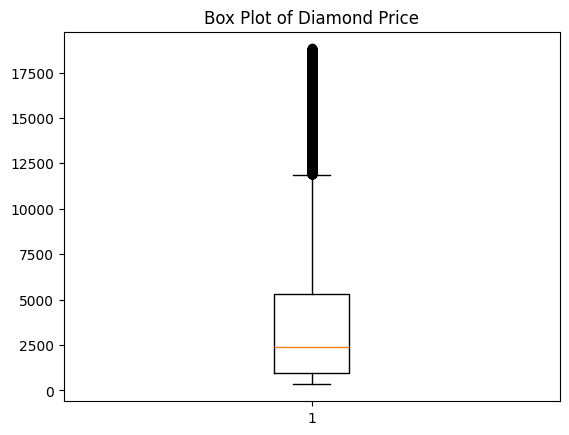

In [ ]:
plt.boxplot(df["price"])
plt.title("Box Plot of Diamond Price")
plt.show()

In [ ]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df = df[(df["price"] >= lower) & (df["price"] <= upper)]

In [ ]:
df["cut"].value_counts()

,count
cut,
Ideal,20392
Premium,12533
Very Good,11325
Good,4641
Fair,1509


In [ ]:
df.describe()

,Unnamed: 0,carat,depth,table,price,x,y,z
count,50400.000000,50400.000000,50400.000000,50400.000000,50400.000000,50400.000000,50400.000000,50400.000000
mean,27054.875000,0.723657,61.755603,57.421873,3159.460833,5.582965,5.586255,3.448359
std,16102.688258,0.383757,1.430780,2.229414,2764.700316,0.994872,0.993937,0.630422
min,1.000000,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,12600.750000,0.380000,61.100000,56.000000,911.000000,4.670000,4.680000,2.880000
50%,28740.500000,0.700000,61.800000,57.000000,2155.000000,5.590000,5.570000,3.430000
75%,41340.250000,1.010000,62.500000,59.000000,4669.000000,6.430000,6.420000,3.980000
max,53940.000000,3.650000,79.000000,79.000000,11883.000000,9.540000,31.800000,31.800000


In [ ]:
df.mean(numeric_only=True)

,0
Unnamed: 0,27054.875000
carat,0.723657
depth,61.755603
table,57.421873
price,3159.460833
x,5.582965
y,5.586255
z,3.448359


In [ ]:
df.median(numeric_only=True)

,0
Unnamed: 0,28740.50
carat,0.70
depth,61.80
table,57.00
price,2155.00
x,5.59
y,5.57
z,3.43


In [ ]:
df.mode().iloc[0]

,0
Unnamed: 0,1
carat,0.3
cut,Ideal
color,G
clarity,SI1
depth,62.0
table,56.0
price,605.0
x,4.37
y,4.34


In [ ]:
df.var(numeric_only=True)

,0
Unnamed: 0,2.592966e+08
carat,1.472697e-01
depth,2.047131e+00
table,4.970288e+00
price,7.643568e+06
x,9.897702e-01
y,9.879101e-01
z,3.974321e-01


In [ ]:
df.std(numeric_only=True)

,0
Unnamed: 0,16102.688258
carat,0.383757
depth,1.430780
table,2.229414
price,2764.700316
x,0.994872
y,0.993937
z,0.630422


In [ ]:
corr = df.corr(numeric_only=True)
print(corr)

            Unnamed: 0     carat     depth     table     price         x  \
Unnamed: 0    1.000000 -0.469400 -0.036216 -0.103444 -0.439486 -0.462140   
carat        -0.469400  1.000000  0.046375  0.183691  0.915825  0.980767   
depth        -0.036216  0.046375  1.000000 -0.291932  0.004075 -0.016122   
table        -0.103444  0.183691 -0.291932  1.000000  0.128120  0.193302   
price        -0.439486  0.915825  0.004075  0.128120  1.000000  0.895808   
x            -0.462140  0.980767 -0.016122  0.193302  0.895808  1.000000   
y            -0.459657  0.972894 -0.019462  0.184486  0.891479  0.990768   
z            -0.451844  0.956139  0.115112  0.144526  0.869637  0.965714   

                   y         z  
Unnamed: 0 -0.459657 -0.451844  
carat       0.972894  0.956139  
depth      -0.019462  0.115112  
table       0.184486  0.144526  
price       0.891479  0.869637  
x           0.990768  0.965714  
y           1.000000  0.959671  
z           0.959671  1.000000  


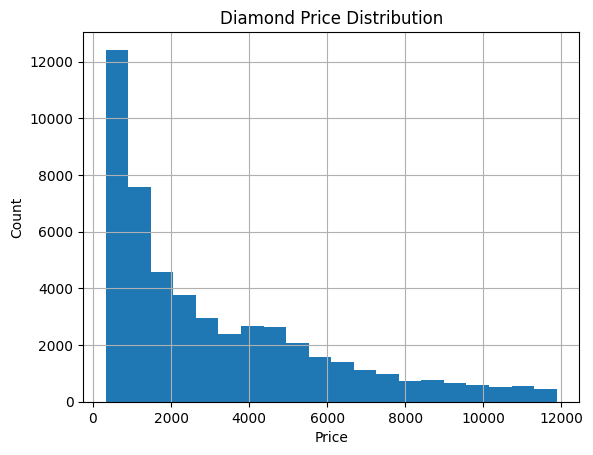

In [ ]:
df["price"].hist(bins=20)
plt.title("Diamond Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

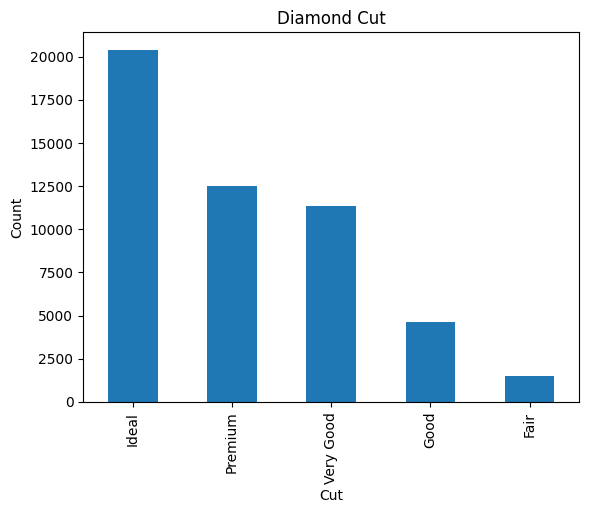

In [ ]:
df["cut"].value_counts().plot(kind="bar")
plt.title("Diamond Cut")
plt.xlabel("Cut")
plt.ylabel("Count")
plt.show()

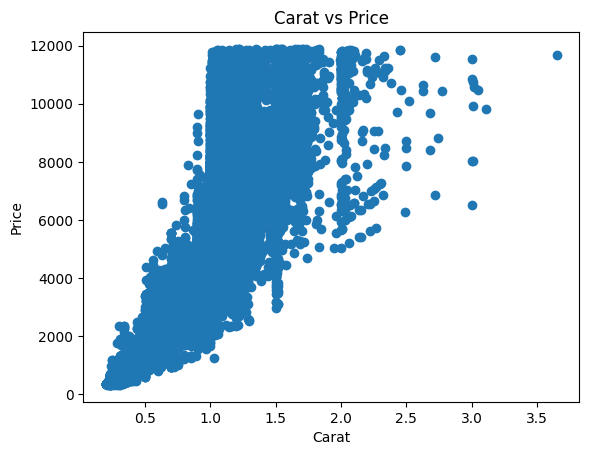

In [ ]:
plt.scatter(df["carat"], df["price"])
plt.title("Carat vs Price")
plt.xlabel("Carat")
plt.ylabel("Price")
plt.show()

1. Diamond price increases as carat increases.

2. Premium and Ideal cuts are more common.

3. Some price outliers were detected and removed.

4. Carat has a strong positive relationship with price.

5. Cleaned data provides better analysis and visualization.

In this project, the Diamonds dataset was downloaded from Kaggle, uploaded to Google Colab, and read using the Pandas library. The dataset was explored by displaying the first few rows, checking the dataset information, shape, and column names to understand its structure. Missing values and duplicate records were identified and handled to improve the quality of the data. Outliers in the diamond price column were detected using a box plot and treated using the Interquartile Range (IQR) method. Both categorical features, such as diamond cut, and numerical features, such as carat and price, were analyzed to understand their impact on diamond prices. Statistical measures including mean, median, mode, variance, and standard deviation were calculated to summarize the numerical data. Correlation analysis was performed to study the relationships between different numerical features. Various visualizations, including a histogram, bar chart, and scatter plot, were created to understand the distribution of diamond prices and the relationship between carat and price. Finally, a business insight report was prepared, showing that the carat weight is one of the most important factors influencing diamond prices. This project helped in understanding data cleaning, outlier detection, statistical analysis, correlation, data visualization, and Exploratory Data Analysis (EDA) using Python, NumPy, Pandas, and Matplotlib.